# Gold Price Prediction: End-to-End Machine Learning Project

This notebook builds a complete gold price forecasting workflow using market data, macroeconomic indicators, feature engineering, model training, evaluation, and dashboard artifact generation.

The final outputs are used by the Streamlit dashboard:

- `model_1day.pkl`
- `model_7day.pkl`
- `model_30day.pkl`
- `latest_features.csv`
- `data/gold.csv`

## 1. Project Introduction

### Problem Statement

Gold prices are influenced by currency movements, inflation, interest rates, investor sentiment, and broader macroeconomic conditions. The goal of this project is to forecast future gold futures prices using historical gold market data and related economic indicators.

### Business Objective

The business objective is to build a simple, interpretable forecasting system that can estimate gold prices over three horizons:

- 1 trading day ahead
- 7 trading days ahead
- 30 trading days ahead

These forecasts can support dashboards, market monitoring, portfolio analysis, and educational analysis of how financial and macroeconomic variables relate to gold prices.

### Why Gold Price Forecasting Matters

Gold is widely used as a store of value, inflation hedge, safe-haven asset, and portfolio diversifier. Forecasting gold prices helps investors, analysts, jewelers, and commodity observers understand potential short-term price movement and the effect of economic indicators such as USDINR, DXY, CPI, and interest rates.

## 2. Environment Setup

This section imports the required libraries, defines project constants, and lists the model features and targets used throughout the notebook.

In [32]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot styling for a clean project notebook.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

# Project paths.
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# Data sources.
START_DATE = "2015-01-01"
GOLD_TICKER = "GC=F"
USDINR_TICKER = "INR=X"
DXY_TICKER = "DX-Y.NYB"

# Unit conversion: GC=F is USD per troy ounce; Indian_Gold is INR per 10 grams.
GRAMS_PER_TROY_OUNCE = 31.1034768
GRAMS_IN_INDIAN_QUOTE = 10

# Model input features. Future target columns are intentionally excluded.
FEATURES = [
    "Close",
    "USDINR",
    "DXY",
    "Interest_Rate",
    "CPI",
    "MA7",
    "MA30",
    "Lag1",
    "Lag7",
    "Return",
    "Volatility",
]

TARGETS = ["Target_1", "Target_7", "Target_30"]
MODEL_FILES = {
    "Target_1": "model_1day.pkl",
    "Target_7": "model_7day.pkl",
    "Target_30": "model_30day.pkl",
}

## 3. Data Collection

This section downloads gold futures prices from Yahoo Finance, along with USDINR, DXY, CPI, and interest-rate data. Yahoo Finance provides daily market data, while FRED provides macroeconomic series through public CSV endpoints.

In [33]:
def flatten_yfinance_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Return a copy with one-level Yahoo Finance column names."""
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    return df


def download_yahoo_ohlcv(ticker: str, start: str) -> pd.DataFrame:
    """Download OHLCV data from Yahoo Finance and normalize the index/columns."""
    df = yf.download(ticker, start=start, auto_adjust=True, progress=True)
    if df.empty:
        raise ValueError(f"No Yahoo Finance data returned for {ticker}")

    df = flatten_yfinance_columns(df)
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df = df.sort_index()
    return df


def download_yahoo_close(ticker: str, start: str, column_name: str) -> pd.Series:
    """Download one Yahoo Finance close series and give it a stable name."""
    df = download_yahoo_ohlcv(ticker, start)
    return df["Close"].rename(column_name)


def download_fred_series(series_id: str, start: str, column_name: str) -> pd.Series:
    """Download one FRED series from FRED's public CSV endpoint."""
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"
    df = pd.read_csv(url, parse_dates=["observation_date"])
    df = df.rename(columns={"observation_date": "Date", series_id: column_name})
    df[column_name] = pd.to_numeric(df[column_name], errors="coerce")
    df = df.dropna(subset=[column_name])
    df = df[df["Date"] >= pd.to_datetime(start)]

    series = df.set_index("Date")[column_name]
    series.index = pd.to_datetime(series.index).tz_localize(None)
    return series.sort_index()

### Download Raw Data

The latest available trading day is downloaded from Yahoo Finance. CPI and interest-rate data may update less frequently because they are macroeconomic series rather than daily market instruments.

In [34]:
gold = download_yahoo_ohlcv(GOLD_TICKER, START_DATE)
usdinr = download_yahoo_close(USDINR_TICKER, START_DATE, "USDINR")
dxy = download_yahoo_close(DXY_TICKER, START_DATE, "DXY")

# FRED macro series:
# FEDFUNDS = Effective Federal Funds Rate
# CPIAUCSL = Consumer Price Index for All Urban Consumers
data_interest_rate = download_fred_series("FEDFUNDS", START_DATE, "Interest_Rate")
data_cpi = download_fred_series("CPIAUCSL", START_DATE, "CPI")

print("Latest Yahoo gold date:", gold.index.max())
print("Latest USDINR date:", usdinr.index.max())
print("Latest DXY date:", dxy.index.max())
print("Latest interest-rate observation:", data_interest_rate.index.max())
print("Latest CPI observation:", data_cpi.index.max())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Latest Yahoo gold date: 2026-07-17 00:00:00
Latest USDINR date: 2026-07-17 00:00:00
Latest DXY date: 2026-07-17 00:00:00
Latest interest-rate observation: 2026-06-01 00:00:00
Latest CPI observation: 2026-06-01 00:00:00


In [35]:
import requests

GRAMS_PER_TROY_OUNCE = 31.1034768
GRAMS_IN_QUOTE = 10

API_KEY = "4eeb047d49b24b1acab4b9ae41d71751ecbcf865be2e101eac5887d2cb2f1397"


def get_live_indian_gold_price():

    url = "https://www.goldapi.io/api/XAU/INR"

    headers = {
        "x-access-token": API_KEY,
        "Content-Type": "application/json"
    }

    response = requests.get(url, headers=headers)

    data = response.json()

    print(data)

    price_per_ounce = data["price"]

    price_per_10g = price_per_ounce * GRAMS_IN_QUOTE / GRAMS_PER_TROY_OUNCE

    return price_per_10g

In [36]:
import requests

url = "https://www.goldapi.io/api/XAU/INR"

headers = {
    "x-access-token": "4eeb047d49b24b1acab4b9ae41d71751ecbcf865be2e101eac5887d2cb2f1397",
    "Content-Type": "application/json"
}

response = requests.get(url, headers=headers)

print(response.status_code)
print(response.json())

403
{'error': 'Invalid API Key'}


In [37]:
# import requests

# url = "https://api.gold-api.com/price/XAU"

# response = requests.get(url)

# print(response.status_code)
# print(response.json())

### Align Market and Economic Data

All external series are aligned to gold trading dates. Missing indicator values are forward-filled so each gold trading day has the most recently available value. A backward fill is applied only to handle rare leading gaps at the beginning of the dataset.

In [38]:
gold = gold.join(usdinr, how="left")
gold = gold.join(dxy, how="left")
gold = gold.join(data_interest_rate, how="left")
gold = gold.join(data_cpi, how="left")

gold[["USDINR", "DXY", "Interest_Rate", "CPI"]] = (
    gold[["USDINR", "DXY", "Interest_Rate", "CPI"]]
    .ffill()
    .bfill()
)

# # Indian gold estimate: USD/oz * INR/USD * 10 grams / troy ounce.
gold["Indian_Gold"] = (
    gold["Close"]
    * gold["USDINR"]
    * GRAMS_IN_INDIAN_QUOTE
    / GRAMS_PER_TROY_OUNCE
)

gold[["Indian_Gold", "USDINR", "DXY", "Interest_Rate", "CPI"]].tail()

,Indian_Gold,USDINR,DXY,Interest_Rate,CPI
Date,,,,,
2026-07-13,122498.849647,95.324997,101.279999,3.63,332.568
2026-07-14,125734.965795,96.298897,100.940002,3.63,332.568
2026-07-15,125369.880070,96.425301,100.500000,3.63,332.568
2026-07-16,123653.319170,96.498596,100.730003,3.63,332.568
2026-07-17,123759.943735,96.342499,100.749001,3.63,332.568


## 4. Exploratory Data Analysis (EDA)

EDA helps us understand the dataset before modeling. The analysis includes dataset shape, missing values, descriptive statistics, trend plots, distributions, correlations, and economic indicator behavior.

### Dataset Overview

This cell shows the size of the dataset, date range, available columns, and the most recent rows after aligning all data sources.

In [39]:
print("Dataset shape:", gold.shape)
print("Start date:", gold.index.min())
print("End date:", gold.index.max())
print("Columns:", list(gold.columns))

gold.tail()

Dataset shape: (2900, 10)
Start date: 2015-01-02 00:00:00
End date: 2026-07-17 00:00:00
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'USDINR', 'DXY', 'Interest_Rate', 'CPI', 'Indian_Gold']


,Close,High,Low,Open,Volume,USDINR,DXY,Interest_Rate,CPI,Indian_Gold
Date,,,,,,,,,,
2026-07-13,3997.000000,4081.000000,3985.899902,4081.000000,679,95.324997,101.279999,3.63,332.568,122498.849647
2026-07-14,4061.100098,4091.199951,3986.500000,3995.699951,1281,96.298897,100.940002,3.63,332.568,125734.965795
2026-07-15,4044.000000,4070.100098,4019.399902,4049.100098,374,96.425301,100.500000,3.63,332.568,125369.880070
2026-07-16,3985.600098,4030.500000,3972.600098,4030.500000,374,96.498596,100.730003,3.63,332.568,123653.319170
2026-07-17,3995.500000,4012.199951,3974.100098,3980.100098,32153,96.342499,100.749001,3.63,332.568,123759.943735


### Missing Value Analysis

Missing values are inspected before feature engineering. Market holidays, macroeconomic reporting frequency, and rolling-window calculations can all create missing values.

In [40]:
missing_summary = pd.DataFrame({
    "Missing_Count": gold.isna().sum(),
    "Missing_Percent": (gold.isna().mean() * 100).round(2),
}).sort_values("Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percent
Close,0,0.0
High,0,0.0
Low,0,0.0
Open,0,0.0
Volume,0,0.0
USDINR,0,0.0
DXY,0,0.0
Interest_Rate,0,0.0
CPI,0,0.0
Indian_Gold,0,0.0


### Descriptive Statistics

Descriptive statistics summarize the central tendency, spread, and range of the core market and macroeconomic variables.

In [41]:
descriptive_columns = ["Close", "Indian_Gold", "USDINR", "DXY", "Interest_Rate", "CPI", "Volume"]
gold[descriptive_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Close,2900.0,1904.674619,889.816265,1050.800049,1276.024994,1732.549988,1978.900024,5318.399902
Indian_Gold,2900.0,48073.741041,28948.758722,22276.701056,27448.410592,42455.526616,52309.344092,157381.052776
USDINR,2900.0,75.042493,8.570904,61.351002,67.184052,73.799702,82.864277,96.565804
DXY,2900.0,98.352438,4.761703,88.589996,94.967501,97.750000,101.550003,114.110001
Interest_Rate,2900.0,2.082766,1.910966,0.050000,0.200000,1.550000,4.090000,5.330000
CPI,2900.0,274.464680,31.289135,236.222000,247.284000,260.319000,306.082000,333.979000
Volume,2900.0,5068.579310,27739.311016,0.000000,54.000000,212.500000,652.500000,386334.000000


### Gold Price Trend Visualization

This plot shows how the gold futures closing price and INR-converted gold estimate changed over time.

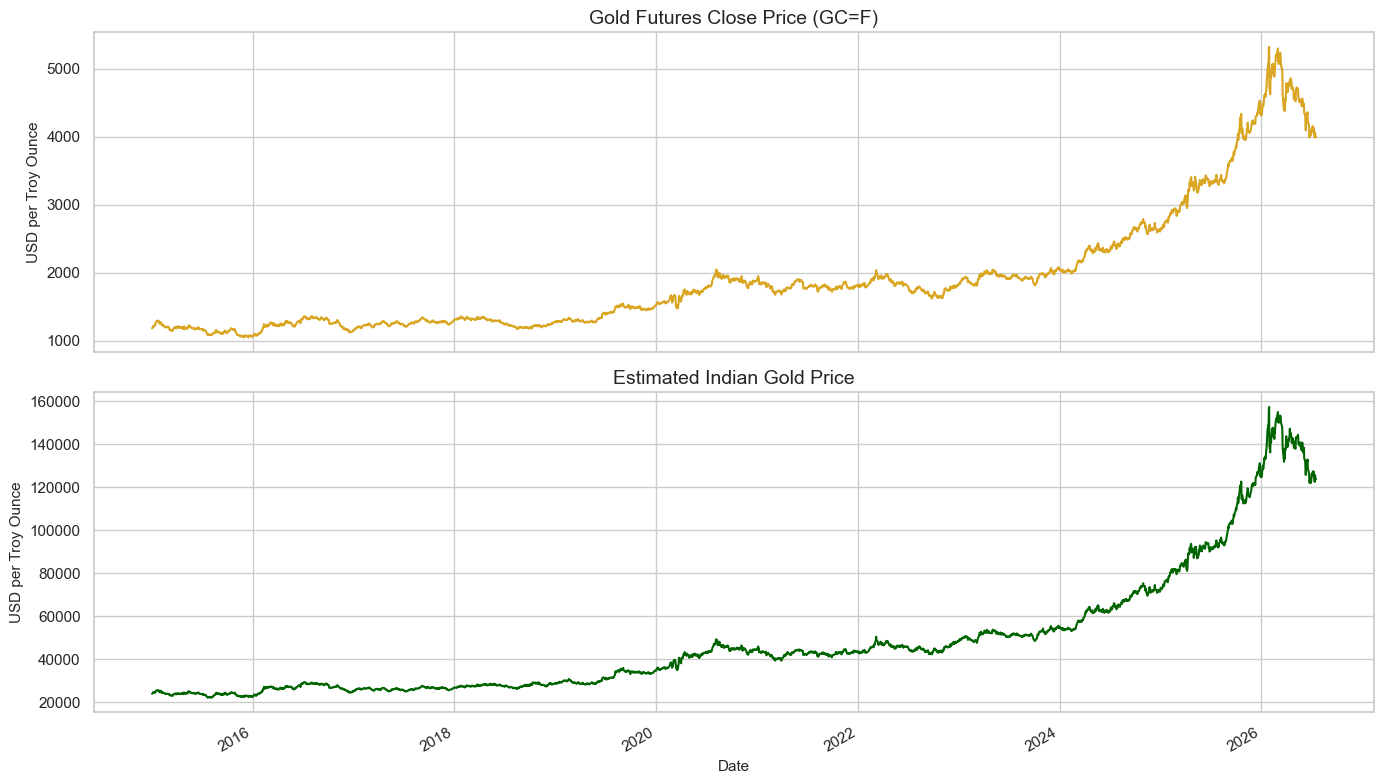

In [42]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

gold["Close"].plot(ax=axes[0], color="goldenrod", linewidth=1.5)
axes[0].set_title("Gold Futures Close Price (GC=F)")
axes[0].set_ylabel("USD per Troy Ounce")

gold["Indian_Gold"].plot(ax=axes[1], color="darkgreen", linewidth=1.5)
axes[1].set_title("Estimated Indian Gold Price")
axes[1].set_ylabel("USD per Troy Ounce")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

### Distribution Plots

Distribution plots show the spread and skewness of gold prices, daily returns, and major economic indicators.

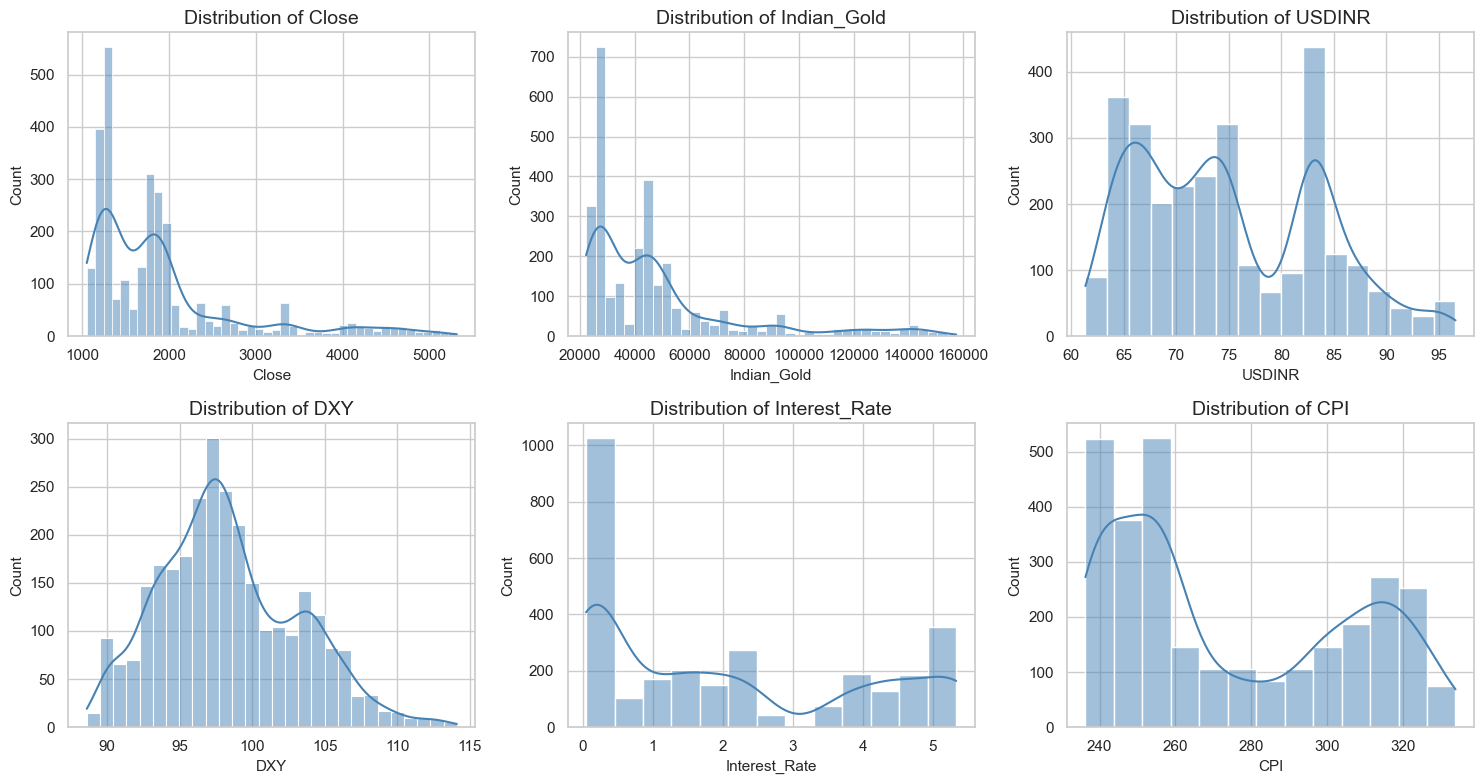

In [43]:
distribution_columns = ["Close", "Indian_Gold", "USDINR", "DXY", "Interest_Rate", "CPI"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, column in zip(axes, distribution_columns):
    sns.histplot(gold[column].dropna(), kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

### Economic Indicators Visualization

This section visualizes USDINR, DXY, CPI, and interest rates to understand the macroeconomic environment around gold prices.

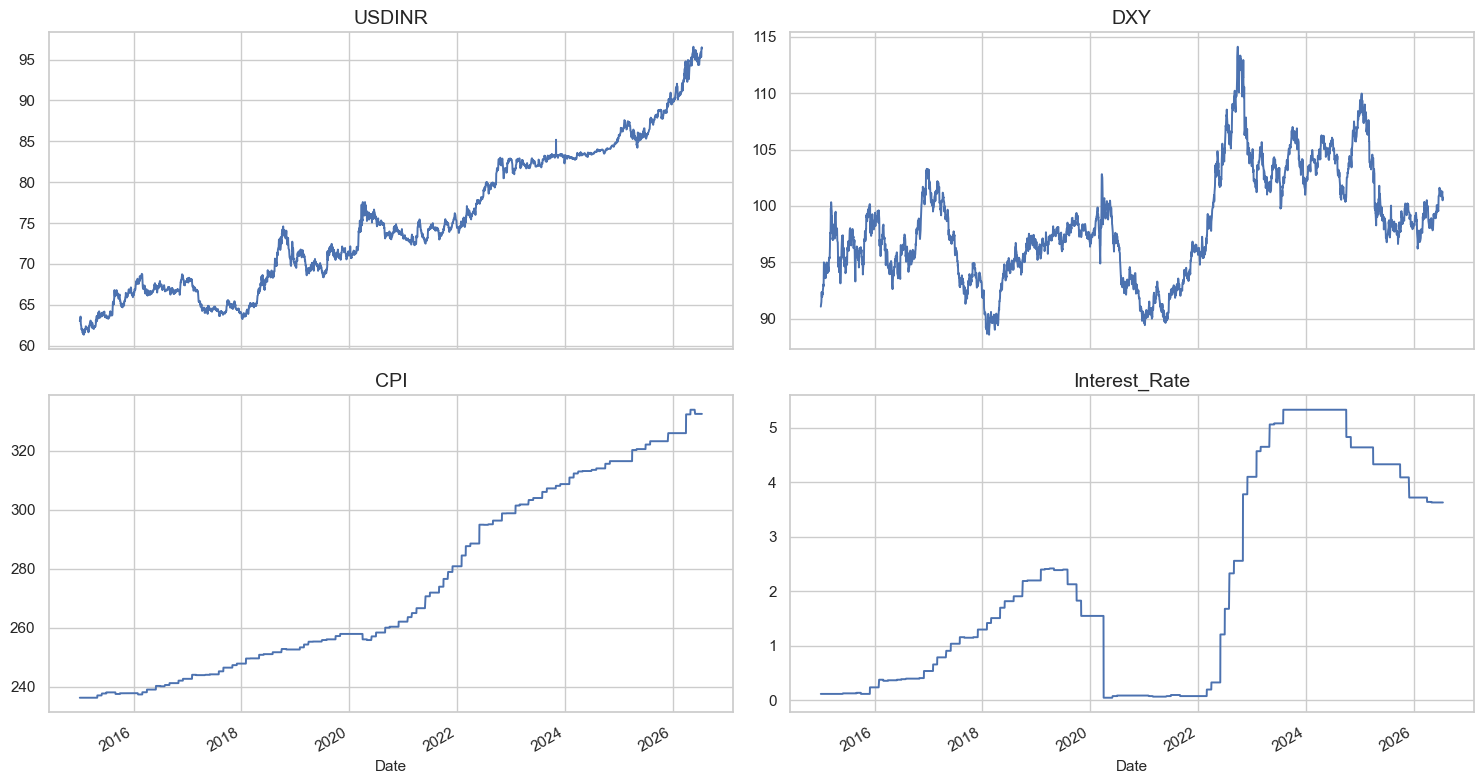

In [44]:
economic_columns = ["USDINR", "DXY", "CPI", "Interest_Rate"]
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
axes = axes.ravel()

for ax, column in zip(axes, economic_columns):
    gold[column].plot(ax=ax, linewidth=1.4)
    ax.set_title(column)
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

## 5. Feature Engineering

The model uses market, technical, and macroeconomic features. All features are created on the full dataframe so the dashboard can always use the latest available market row.

Feature explanations:

- **Indian_Gold**: Gold price converted from USD per troy ounce into INR per 10 grams.
- **USDINR**: Exchange rate between the US dollar and Indian rupee.
- **DXY**: US Dollar Index, a measure of USD strength against major currencies.
- **Interest_Rate**: Effective federal funds rate from FRED.
- **CPI**: Consumer Price Index from FRED, used as an inflation indicator.
- **MA7**: 7-day moving average of gold close price, capturing short-term trend.
- **MA30**: 30-day moving average of gold close price, capturing medium-term trend.
- **Lag1**: Previous trading day's close price.
- **Lag7**: Close price from seven trading days earlier.
- **Return**: Daily percentage change in gold close price.
- **Volatility**: 30-day rolling standard deviation of close price.

In [45]:
# Moving averages capture trend information from current and historical prices.
gold["MA7"] = gold["Close"].rolling(window=7).mean()
gold["MA30"] = gold["Close"].rolling(window=30).mean()

# Lag features capture recent historical price levels.
gold["Lag1"] = gold["Close"].shift(1)
gold["Lag7"] = gold["Close"].shift(7)

# Return captures daily percentage movement; volatility captures recent price dispersion.
gold["Return"] = gold["Close"].pct_change()
gold["Volatility"] = gold["Close"].rolling(window=30).std()

gold[FEATURES].tail()

,Close,USDINR,DXY,Interest_Rate,CPI,MA7,MA30,Lag1,Lag7,Return,Volatility
Date,,,,,,,,,,,
2026-07-13,3997.000000,95.324997,101.279999,3.63,332.568,4102.242885,4208.873348,4104.100098,4068.300049,-0.026096,165.817678
2026-07-14,4061.100098,96.298897,100.940002,3.63,332.568,4094.871443,4192.226685,3997.000000,4112.700195,0.016037,153.942651
2026-07-15,4044.000000,96.425301,100.500000,3.63,332.568,4079.000000,4177.853345,4061.100098,4155.100098,-0.004211,146.564239
2026-07-16,3985.600098,96.498596,100.730003,3.63,332.568,4056.185756,4161.070011,4044.000000,4145.299805,-0.014441,138.288500
2026-07-17,3995.500000,96.342499,100.749001,3.63,332.568,4045.414342,4146.363338,3985.600098,4070.899902,0.002484,131.246072


### Feature Visualization

Moving averages and lag values are plotted against the gold close price to visually inspect the engineered technical features.

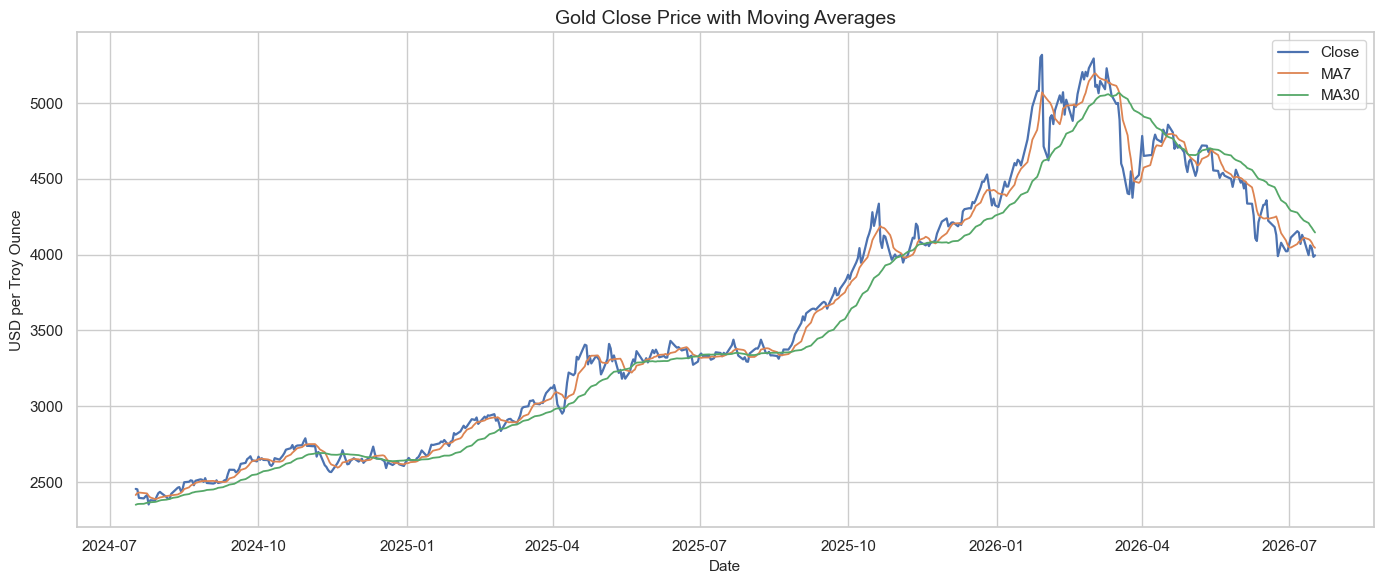

In [46]:
plot_start = gold.index.max() - pd.DateOffset(years=2)
recent_gold = gold.loc[gold.index >= plot_start]

plt.figure(figsize=(14, 6))
plt.plot(recent_gold.index, recent_gold["Close"], label="Close", linewidth=1.6)
plt.plot(recent_gold.index, recent_gold["MA7"], label="MA7", linewidth=1.3)
plt.plot(recent_gold.index, recent_gold["MA30"], label="MA30", linewidth=1.3)
plt.title("Gold Close Price with Moving Averages")
plt.ylabel("USD per Troy Ounce")
plt.xlabel("Date")
plt.legend()
plt.tight_layout()
plt.show()

### Target Creation

The targets are future gold futures closing prices. These shifts intentionally create missing values at the end of the dataframe because future prices are not available yet.

Important: the full dataframe is not overwritten with `dropna()`. Only `train_data` drops missing values for model training.

In [47]:
gold["Target_1"] = gold["Close"].shift(-1)
gold["Target_7"] = gold["Close"].shift(-7)
gold["Target_30"] = gold["Close"].shift(-30)

print("Latest full data date:", gold.index.max())
print("Missing values after feature and target creation:")
print(gold[FEATURES + TARGETS].isna().sum())

gold[["Close", "Target_1", "Target_7", "Target_30"]].tail(35)

Latest full data date: 2026-07-17 00:00:00
Missing values after feature and target creation:
Close             0
USDINR            0
DXY               0
Interest_Rate     0
CPI               0
MA7               6
MA30             29
Lag1              1
Lag7              7
Return            1
Volatility       29
Target_1          1
Target_7          7
Target_30        30
dtype: int64


,Close,Target_1,Target_7,Target_30
Date,,,,
2026-05-28,4499.299805,4560.500000,4335.899902,3997.000000
2026-05-29,4560.500000,4475.200195,4260.000000,4061.100098
2026-06-01,4475.200195,4489.100098,4108.200195,4044.000000
2026-06-02,4489.100098,4436.700195,4090.300049,3985.600098
2026-06-03,4436.700195,4475.799805,4215.000000,3995.500000
2026-06-04,4475.799805,4337.100098,4328.000000,NaN
2026-06-05,4337.100098,4335.899902,4330.899902,NaN
2026-06-08,4335.899902,4260.000000,4358.899902,NaN
2026-06-09,4260.000000,4108.200195,4224.100098,NaN


### Correlation Heatmap

The correlation heatmap helps identify relationships among model features and targets. Strong correlations are expected between current gold prices, lagged prices, moving averages, and future gold prices.

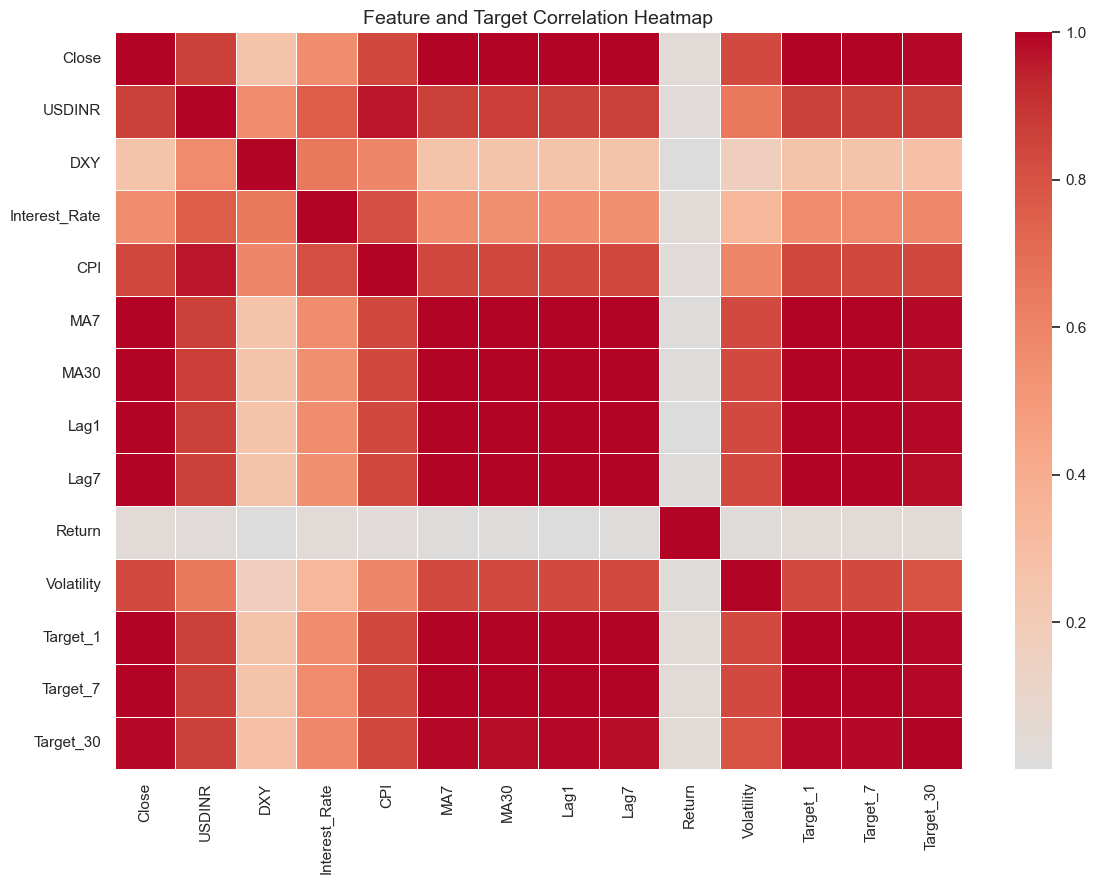

In [48]:
correlation_columns = FEATURES + TARGETS
corr = gold[correlation_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.5)
plt.title("Feature and Target Correlation Heatmap")
plt.tight_layout()
plt.show()

## 6. Model Development

A chronological train/test split is used because this is a time-series forecasting problem. Random shuffling would allow future market regimes to influence past training examples, creating look-ahead bias.

The notebook evaluates each model on the latest 20% of trainable rows and then refits the final saved model on all rows where the target is available.

In [49]:
# Save the full engineered dataframe, including latest rows whose future targets are unknown.
gold.to_csv(DATA_DIR / "gold.csv")

# Only the training dataframe drops missing values.
train_data = gold.dropna()

print("Latest full data date:", gold.index.max())
print("Latest training date:", train_data.index.max())
print("Full dataframe shape:", gold.shape)
print("Training dataframe shape:", train_data.shape)

assert gold.index.max() > train_data.index.max(), (
    "Expected training data to end earlier than full data because future targets are unavailable."
)
assert not train_data[FEATURES + TARGETS].isna().any().any(), "Training data still contains NaNs."

Latest full data date: 2026-07-17 00:00:00
Latest training date: 2026-06-03 00:00:00
Full dataframe shape: (2900, 19)
Training dataframe shape: (2841, 19)


### Train/Test Split and Linear Regression Training

Linear Regression is used because it is interpretable, fast, and suitable as a baseline regression model. Each horizon receives its own separate model.

In [50]:
def chronological_train_test_split(df: pd.DataFrame, target_col: str, test_size: float = 0.2):
    """Split time-series data without shuffling to avoid look-ahead bias."""
    split_idx = int(len(df) * (1 - test_size))
    X = df[FEATURES]
    y = df[target_col]

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]
    return X_train, X_test, y_train, y_test


def evaluate_and_train_final_model(df: pd.DataFrame, target_col: str) -> tuple[LinearRegression, dict, pd.DataFrame]:
    """Evaluate chronologically, compare with a naive baseline, then refit on all valid rows."""
    X_train, X_test, y_train, y_test = chronological_train_test_split(df, target_col)

    validation_model = LinearRegression()
    validation_model.fit(X_train, y_train)
    model_preds = validation_model.predict(X_test)

    # Naive baseline: assume the future close equals the current close.
    naive_preds = df.loc[X_test.index, "Close"]

    metrics = {
        "Target": target_col,
        "Horizon": target_col.replace("Target_", "") + " day(s)",
        "Model_MAE": mean_absolute_error(y_test, model_preds),
        "Model_RMSE": mean_squared_error(y_test, model_preds) ** 0.5,
        "Model_R2": r2_score(y_test, model_preds),
        "Naive_MAE": mean_absolute_error(y_test, naive_preds),
        "Naive_RMSE": mean_squared_error(y_test, naive_preds) ** 0.5,
        "Naive_R2": r2_score(y_test, naive_preds),
        "Train_Start": X_train.index.min(),
        "Train_End": X_train.index.max(),
        "Test_Start": X_test.index.min(),
        "Test_End": X_test.index.max(),
    }

    validation_predictions = pd.DataFrame({
        "Actual": y_test,
        "Predicted": model_preds,
        "Naive": naive_preds,
    }, index=X_test.index)

    # Refit on every row with a valid target before saving for dashboard predictions.
    final_model = LinearRegression()
    final_model.fit(df[FEATURES], df[target_col])

    return final_model, metrics, validation_predictions

## 7. Model Evaluation

The models are evaluated using:

- **MAE**: Average absolute forecast error.
- **RMSE**: Penalizes larger errors more strongly than MAE.
- **R²**: Measures variance explained by the model.
- **Naive baseline**: Assumes the future close equals the current close.

In [57]:
models = {}
metrics_rows = []
prediction_frames = {}

for target_col, model_file in MODEL_FILES.items():
    model, metrics, validation_predictions = evaluate_and_train_final_model(train_data, target_col)
    models[target_col] = model
    metrics_rows.append(metrics)
    prediction_frames[target_col] = validation_predictions
    joblib.dump(model, model_file)
    print(f"Saved {model_file}")

metrics_df = pd.DataFrame(metrics_rows)
metrics_df

Saved model_1day.pkl
Saved model_7day.pkl
Saved model_30day.pkl


,Target,Horizon,Model_MAE,Model_RMSE,Model_R2,Naive_MAE,Naive_RMSE,Naive_R2,Train_Start,Train_End,Test_Start,Test_End
0,Target_1,1 day(s),37.258364,58.277372,0.995741,35.404042,57.350941,0.995875,2015-02-13,2024-02-28,2024-02-29,2026-06-03
1,Target_7,7 day(s),107.211352,152.051188,0.970756,95.101230,140.646544,0.974979,2015-02-13,2024-02-28,2024-02-29,2026-06-03
2,Target_30,30 day(s),259.396301,340.340643,0.847066,218.840422,286.860682,0.891353,2015-02-13,2024-02-28,2024-02-29,2026-06-03


In [ ]:
import os

os.makedirs("data", exist_ok=True)

prediction_frames["Target_1"]\
    .reset_index()\
    .to_csv("data/results_1day.csv", index=False)

prediction_frames["Target_7"]\
    .reset_index()\
    .to_csv("data/results_7day.csv", index=False)

prediction_frames["Target_30"]\
    .reset_index()\
    .to_csv("data/results_30day.csv", index=False)

print("Saved validation predictions.")

In [59]:
import os

os.makedirs("data", exist_ok=True)

In [61]:
prediction_frames["Target_1"]\
    .reset_index()\
    .rename(columns={"index":"Date"})\
    .to_csv(
        "data/results_1day.csv",
        index=False
    )
prediction_frames["Target_7"]\
    .reset_index()\
    .rename(columns={"index":"Date"})\
    .to_csv(
        "data/results_7day.csv",
        index=False
    )

prediction_frames["Target_30"]\
    .reset_index()\
    .rename(columns={"index":"Date"})\
    .to_csv(
        "data/results_30day.csv",
        index=False
    )

print("Validation results saved.")

Validation results saved.


### Results Summary Table

This table compares Linear Regression against the naive baseline for the 1-day, 7-day, and 30-day forecasting horizons.

In [62]:
summary_columns = [
    "Target",
    "Horizon",
    "Model_MAE",
    "Model_RMSE",
    "Model_R2",
    "Naive_MAE",
    "Naive_RMSE",
    "Naive_R2",
    "Train_End",
    "Test_Start",
    "Test_End",
]

results_summary = metrics_df[summary_columns].copy()
results_summary[["Model_MAE", "Model_RMSE", "Model_R2", "Naive_MAE", "Naive_RMSE", "Naive_R2"]] = (
    results_summary[["Model_MAE", "Model_RMSE", "Model_R2", "Naive_MAE", "Naive_RMSE", "Naive_R2"]]
    .round(3)
)

results_summary

,Target,Horizon,Model_MAE,Model_RMSE,Model_R2,Naive_MAE,Naive_RMSE,Naive_R2,Train_End,Test_Start,Test_End
0,Target_1,1 day(s),37.258,58.277,0.996,35.404,57.351,0.996,2024-02-28,2024-02-29,2026-06-03
1,Target_7,7 day(s),107.211,152.051,0.971,95.101,140.647,0.975,2024-02-28,2024-02-29,2026-06-03
2,Target_30,30 day(s),259.396,340.341,0.847,218.840,286.861,0.891,2024-02-28,2024-02-29,2026-06-03


## 8. Model Visualizations

This section visualizes actual vs predicted values and feature coefficients for interpretability.

### Actual vs Predicted Plots

Actual vs predicted plots show how closely each model follows the test-period gold futures price.

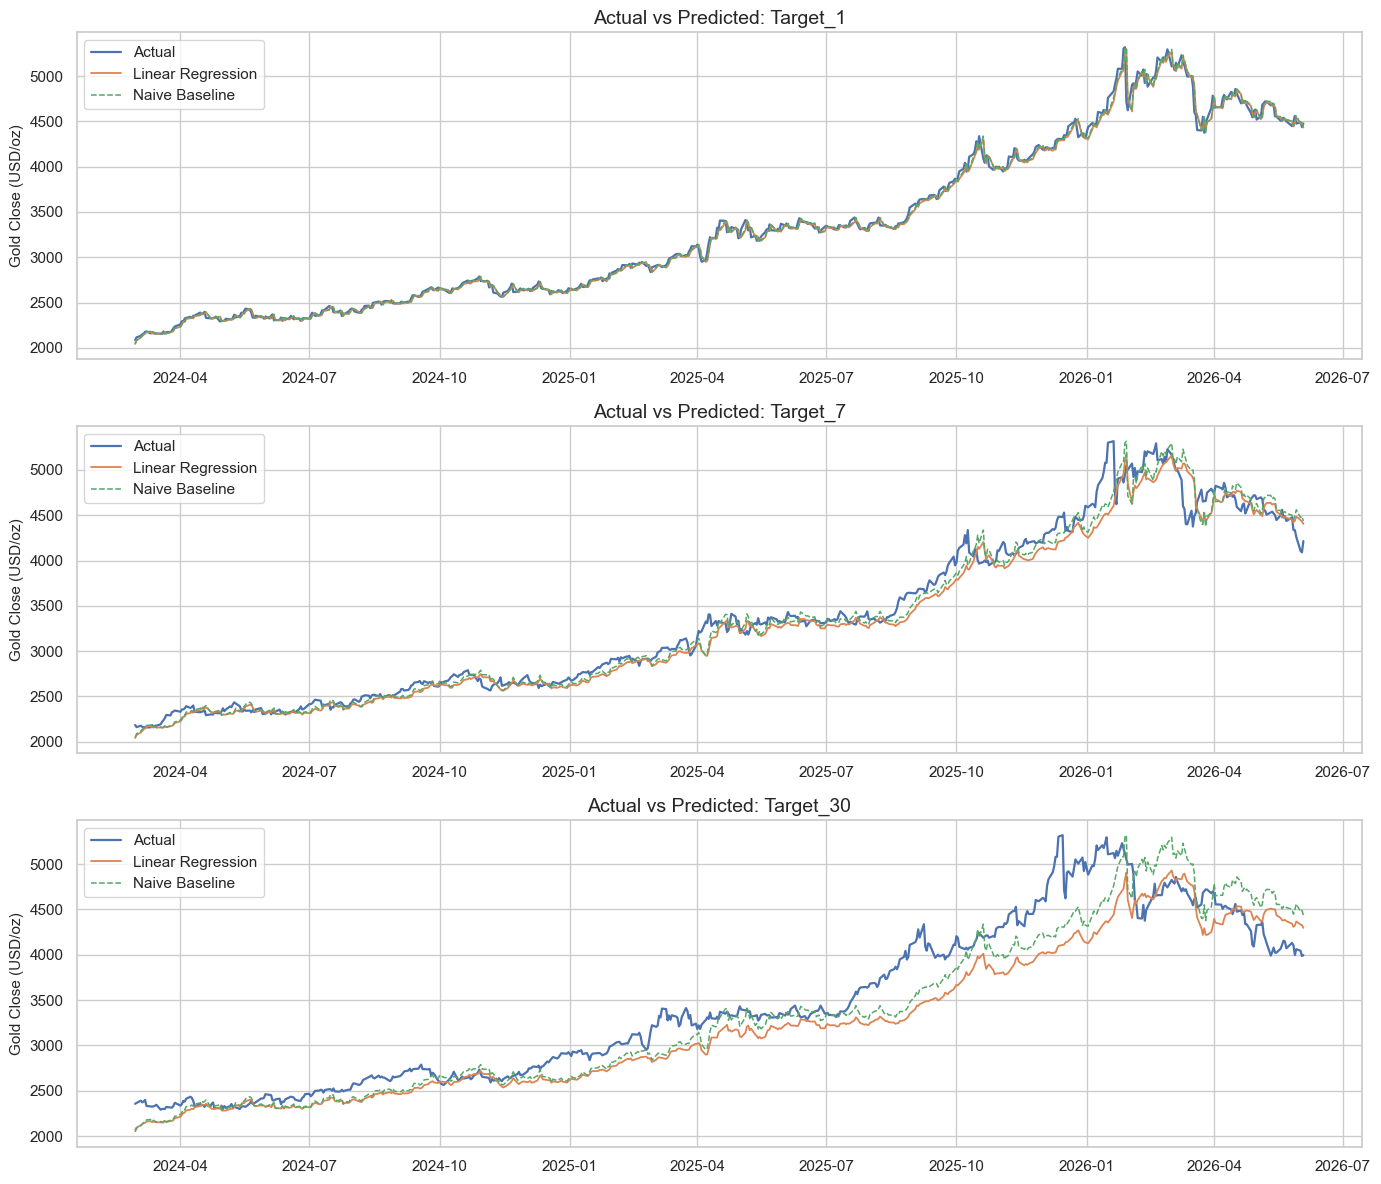

In [63]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)

for ax, target_col in zip(axes, TARGETS):
    predictions = prediction_frames[target_col]
    ax.plot(predictions.index, predictions["Actual"], label="Actual", linewidth=1.6)
    ax.plot(predictions.index, predictions["Predicted"], label="Linear Regression", linewidth=1.3)
    ax.plot(predictions.index, predictions["Naive"], label="Naive Baseline", linewidth=1.1, linestyle="--")
    ax.set_title(f"Actual vs Predicted: {target_col}")
    ax.set_ylabel("Gold Close (USD/oz)")
    ax.legend()

plt.tight_layout()
plt.show()

### Feature Coefficient Plots

Linear Regression coefficients show the direction and magnitude of each feature's contribution. Because the features are not standardized, coefficient magnitudes should be interpreted carefully and mainly used as a directional diagnostic.

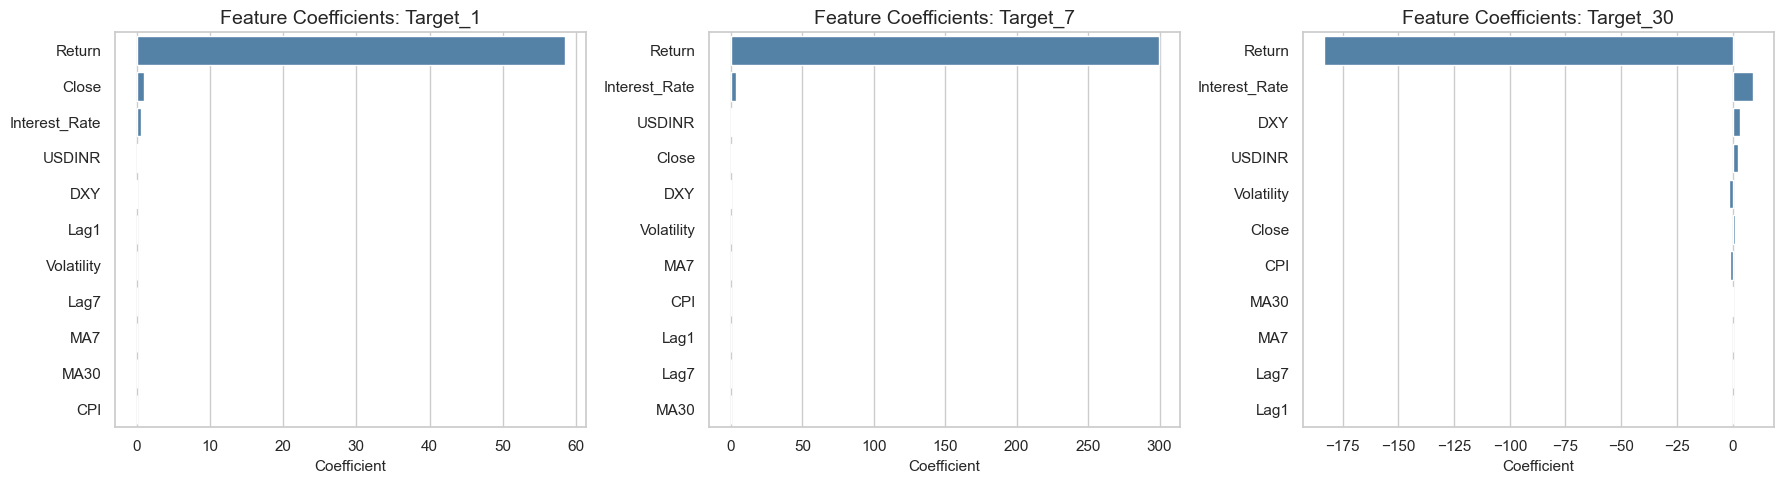

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, target_col in zip(axes, TARGETS):
    coefficient_df = pd.DataFrame({
        "Feature": FEATURES,
        "Coefficient": models[target_col].coef_,
    }).sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)

    sns.barplot(data=coefficient_df, y="Feature", x="Coefficient", ax=ax, color="steelblue")
    ax.set_title(f"Feature Coefficients: {target_col}")
    ax.set_xlabel("Coefficient")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 9. Dashboard Artifact Generation

The dashboard must always use the newest available market data, even though the training dataframe ends earlier because future targets are unavailable.

This section saves `latest_features.csv` from the full dataframe, not from `train_data`.

In [65]:
latest = gold[FEATURES].tail(1)

print("Latest full data date:", gold.index.max())
print("Latest training date:", train_data.index.max())
print("Latest dashboard feature date:", latest.index.max())

assert latest.index.max() == gold.index.max(), "latest_features.csv is not using the newest full-data row."
assert not latest.isna().any().any(), "Latest feature row contains NaNs; dashboard predictions would fail."

# Save date as a column so Streamlit can display the data freshness.
latest.to_csv("latest_features.csv", index=True, index_label="Date")
latest

Latest full data date: 2026-07-17 00:00:00
Latest training date: 2026-06-03 00:00:00
Latest dashboard feature date: 2026-07-17 00:00:00


,Close,USDINR,DXY,Interest_Rate,CPI,MA7,MA30,Lag1,Lag7,Return,Volatility
Date,,,,,,,,,,,
2026-07-17,3995.5,96.342499,100.749001,3.63,332.568,4045.414342,4146.363338,3985.600098,4070.899902,0.002484,131.246072


### End-to-End Prediction Check

This final check loads the exact dashboard feature row and confirms all three saved models can generate predictions from it.

In [68]:
latest_from_csv = pd.read_csv("latest_features.csv")
X_latest = latest_from_csv[FEATURES]

print("Dashboard date:", latest_from_csv["Date"].iloc[0])
print("Current us gold estimate:", latest_from_csv["Close"].iloc[0])
print("1-day forecast, GC=F Close:", models["Target_1"].predict(X_latest)[0])
print("7-day forecast, GC=F Close:", models["Target_7"].predict(X_latest)[0])
print("30-day forecast, GC=F Close:", models["Target_30"].predict(X_latest)[0])

Dashboard date: 2026-07-17
Current us gold estimate: 3995.5
1-day forecast, GC=F Close: 4003.92237142775
7-day forecast, GC=F Close: 4035.4590345050697
30-day forecast, GC=F Close: 3988.5998343570927


## 10. Leakage and Bias Review

This review documents the modeling safeguards used in the notebook.

In [69]:
leakage_review = [
    "The full dataframe is preserved after feature engineering.",
    "train_data = gold.dropna() is the only dropna step used for training.",
    "Future target columns are never included in FEATURES.",
    "The train/test split is chronological and never shuffled.",
    "No scaler is used for LinearRegression, so there is no scaling leakage.",
    "Rolling and lag features use current/past prices only.",
    "latest_features.csv is generated from gold[FEATURES].tail(1), so Streamlit uses the latest market row.",
    "FRED monthly values are forward-filled onto trading dates; for production-grade macro modeling, release-date vintages should be considered.",
]

pd.DataFrame({"Review_Item": leakage_review})

,Review_Item
0,The full dataframe is preserved after feature ...
1,train_data = gold.dropna() is the only dropna ...
2,Future target columns are never included in FE...
3,The train/test split is chronological and neve...
4,"No scaler is used for LinearRegression, so the..."
5,Rolling and lag features use current/past pric...
6,latest_features.csv is generated from gold[FEA...
7,FRED monthly values are forward-filled onto tr...


## 11. Conclusion

### Key Findings

- The full dataset can contain the latest Yahoo Finance trading date while the training dataset ends earlier because future target values are unavailable.
- Linear Regression provides an interpretable baseline for 1-day, 7-day, and 30-day gold futures forecasting.
- Lagged prices, moving averages, USDINR, DXY, CPI, and interest rates provide a useful combination of market and macroeconomic context.
- The Streamlit dashboard should always read the latest full-data feature row, not the truncated training dataset.

### Limitations

- Linear Regression may not capture nonlinear market behavior.
- FRED macroeconomic data is forward-filled and does not model exact publication lag or vintage revisions.
- The targets forecast `GC=F` close prices, while dashboard INR values require conversion using the latest USDINR.
- Financial markets are noisy, and short-term gold price movements can be affected by news events not present in the dataset.

### Future Improvements

- Add walk-forward validation for more robust time-series evaluation.
- Compare Linear Regression with Ridge, Lasso, Random Forest, XGBoost, and time-series models.
- Add prediction intervals to communicate uncertainty.
- Use release-date-aware macroeconomic data to reduce macro look-ahead risk.
- Automate scheduled retraining and dashboard artifact refresh.

In [70]:
history = gold.reset_index()

history.to_csv(
    "history.csv",
    index=False
)

print("history.csv saved.")

history.csv saved.
